In [16]:
import torch
import torch.nn.functional as F
import torch.nn as nn
# import torch.optim as optim
# import torch_optimizer as optim
import torch.nn.init as init

import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
import adabound
from sys import stdout
from tqdm import tqdm
from tqdm import trange
import seaborn as sns

import time
from datetime import datetime as dt

from tensorflow.keras.models import load_model

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/zorocrit/Control_Nuclear_Spins/master/C13spin/testdata.csv?token=GHSAT0AAAAAAB5HMDTB2GTBZHJM4PEGNKE2ZCHHGNA')
# df

In [5]:
# y = df[['x', 'N', 'z']]
# # y

y = df[['Xtau', 'XN']]
y

,Xtau,XN
0,2.959641,10.0
1,4.245750,7.0
2,3.594517,10.0
3,0.479873,16.0
4,2.861716,13.0
...,...,...
36744,2.910000,13.0
36745,4.258442,9.0
36746,1.675000,13.0
36747,2.935000,22.0


In [6]:
X = df[['Al', 'Ap']]
# X

In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.10, random_state=100)

In [8]:
Xdata = list(np.array(X_train.values.tolist()))
print(Xdata.__len__())

33074


In [9]:
ydata = list(np.array(y_train.values.tolist()))
# print(ydata)

In [10]:
torch.manual_seed(1)

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for reproducibility
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)
print(device)

cpu


In [12]:
x = torch.FloatTensor(Xdata).to(device)
y = torch.FloatTensor(ydata).to(device)

C:\Users\KIST3\AppData\Local\Temp\ipykernel_8888\2245922195.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:248.)
  x = torch.FloatTensor(Xdata).to(device)


In [13]:
num_data = Xdata.__len__()

num_epoch = 2000000

In [27]:
from sys import stdout


model = nn.Sequential(

    nn.Linear(2,300),

    nn.ReLU(),

    nn.Linear(300,300),

    nn.ReLU(),

    nn.Linear(300,300),

    nn.ReLU(),
    
    nn.Linear(300,300),

    nn.ReLU(),
    
    nn.Linear(300,300),

    nn.ReLU(),
    
    nn.Linear(300,300),

    nn.ReLU(),
    
    nn.Linear(300,300),

    nn.ReLU(),
    
    nn.Linear(300,300),

    nn.ReLU(),

    nn.Linear(300,2)

).to(device)

#ReLU라는 Activation Function을 사용하여, 4개의 Linear Layer로 모델 구현

# Input layer에 1개씩 데이터가 들어가므로 nn.Linear(1,2)이며, 최종적으로 1개의 값이 나와야하기에 Output Layer는 nn.Linear(4,1)



In [ ]:
 

loss_func = nn.L1Loss().to(device)

# optimizer = optim.SGD(model.parameters(),lr = 0.0002)

# optimizer = adabound.AdaBound(model.parameters(), lr=0.935 * 1e-4, final_lr=0.05758)  #Loss: 0.0537

# optimizer = adabound.AdaBound(model.parameters(), lr=0.435 * 1e-3, final_lr=0.05558)

optimizer = adabound.AdaBound(model.parameters(), lr=0.935 * 1e-3, final_lr=0.04978)  #Loss: 0.0537

loss_array = []

minloss = 10

for i in tqdm(range(num_epoch)) : 

    optimizer.zero_grad()

    output = model(x)

    loss = loss_func(output,y)

    loss.backward()

    optimizer.step()

    if(loss < minloss):
       minloss = loss

    loss_array.append(loss)
    if(i == 1):
      stdout.write("Minimum loss: " + str(minloss))
    if(i%100000 == 0 and i != 0):
      # print("Case "+ str(i) + ", Loss: " + str(loss.data))
      stdout.write("Minimum loss: " + str(minloss))

    if i == num_epoch - 1:

        print(loss.data)

        param_list = list(model.parameters())

        #최종 학습된 마지막 결과물의 Parameter 저장

        print(param_list)

loss_array = torch.tensor(loss_array)

loss_array.detach().numpy()

plt.plot(loss_array)

plt.show()

#Loss(y_predicted - y_real)값이 어떻게 변하는지 그래프로 도식화

In [13]:
from datetime import datetime as dt
date = dt.now()

printdate = date.strftime('%Y%m%d_%H%M%S')
print(date)

torch.save(model.state_dict(), "Xmodel_" + printdate + ".h5")

2023-04-19 17:35:55.364353


In [29]:
# model = load_model("C:/Users/KIST3/Desktop/13C/ml_04.11/Xmodel_20230419_173555.h5")
model.load_state_dict(torch.load("Xmodel_20230419_173555.h5"))
model.eval()

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [14]:
X_2 = list(np.array(X.values.tolist()))
X_2_tensor = torch.FloatTensor(X_2).to(device)
y_2_input = model(X_2_tensor)
y_2_input = np.array(y_2_input.tolist())
y_2_input

array([[ 2.96878314,  9.99699211],
       [ 4.43640757,  6.98709822],
       [ 3.61910915, 10.01675224],
       ...,
       [ 1.68283617, 13.00478935],
       [ 2.94162321, 21.95354843],
       [ 3.10761261,  6.99611521]])

In [17]:
X_input = list(np.array(X_valid.values.tolist()))
new_var =  torch.FloatTensor(X_input).to(device)
y_input = model(new_var)
y_input = np.array(y_input.tolist())
y_input

array([[ 1.47154427,  9.91406155],
       [ 4.16308784, 10.01140594],
       [ 1.37726974,  6.9969573 ],
       ...,
       [ 1.47109938,  6.47761822],
       [ 4.35566902, 22.13625526],
       [ 4.0169878 ,  7.42738152]])

In [18]:
y_output = np.array(y_valid.values.tolist())
y_output

array([[ 4.35176188, 10.        ],
       [ 1.91      , 10.        ],
       [ 1.36831193,  7.        ],
       ...,
       [ 1.44176854,  7.        ],
       [ 4.37756871, 22.        ],
       [ 1.57982355, 10.        ]])

In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# MAE
print("X tau MAE: " + str(mean_absolute_error(y_input[:, 0], y_output[:, 0])))
print("X N MAE: " + str(mean_absolute_error(y_input[:, 1], y_output[:, 1])))
# print("Z tau MAE: " + str(mean_absolute_error(y_input[:, 2], y_output[:, 2])))
# print("Z N MAE: " + str(mean_absolute_error(y_input[:, 3], y_output[:, 3])))

print(' ')
#MSE
print("X tau MSE: " + str(mean_squared_error(y_input[:, 0], y_output[:, 0])))
print("X N MSE: " + str(mean_squared_error(y_input[:, 1], y_output[:, 1])))
# print("Z tau MSE: " + str(mean_squared_error(y_input[:, 2], y_output[:, 2])))
# print("Z N MSE: " + str(mean_squared_error(y_input[:, 3], y_output[:, 3])))

print(' ')
#r2
print("X tau r2: " + str(r2_score(y_input[:, 0], y_output[:, 0])))
print("X N r2: " + str(r2_score(y_input[:, 1], y_output[:, 1])))
# print("Z tau r2: " + str(r2_score(y_input[:, 2], y_output[:, 2])))
# print("Z N r2: " + str(r2_score(y_input[:, 3], y_output[:, 3])))

X tau MAE: 0.27119007768984915
X N MAE: 1.5229436329432897
 
X tau MSE: 0.5187859273667293
X N MSE: 16.648143375054108
 
X tau r2: 0.7098479656514509
X N r2: 0.31470413918845497


In [20]:
y2 = df[['Ztau', 'ZN']]
y2

,Ztau,ZN
0,0.176380,1.0
1,0.625249,22.0
2,1.129403,1.0
3,0.059788,1.0
4,0.197018,4.0
...,...,...
36744,1.273125,10.0
36745,2.132500,1.0
36746,0.209375,7.0
36747,0.917188,1.0


In [21]:
x2 = df[['Al', 'Ap']]
x2

,Al,Ap
0,1.977370,0.765909
1,2.673387,1.847034
2,0.572199,1.815541
3,1.159075,0.425780
4,4.427746,0.920076
...,...,...
36744,4.275027,0.802606
36745,4.104650,1.576277
36746,3.926686,0.789887
36747,2.068772,0.314327


In [22]:
x2_2 = y_2_input
x2_2 = pd.DataFrame(x2_2)
x2_2.rename(columns={0: "Xtau_pre", 1: "XN_pre"}, inplace=True)
x2_2

,Xtau_pre,XN_pre
0,2.968783,9.996992
1,4.436408,6.987098
2,3.619109,10.016752
3,0.487028,15.999538
4,2.876117,13.003597
...,...,...
36744,2.922970,13.003338
36745,4.259301,9.045466
36746,1.682836,13.004789
36747,2.941623,21.953548


In [23]:
x2_fin = pd.concat([x2, x2_2], axis = 1)
x2_fin

,Al,Ap,Xtau_pre,XN_pre
0,1.977370,0.765909,2.968783,9.996992
1,2.673387,1.847034,4.436408,6.987098
2,0.572199,1.815541,3.619109,10.016752
3,1.159075,0.425780,0.487028,15.999538
4,4.427746,0.920076,2.876117,13.003597
...,...,...,...,...
36744,4.275027,0.802606,2.922970,13.003338
36745,4.104650,1.576277,4.259301,9.045466
36746,3.926686,0.789887,1.682836,13.004789
36747,2.068772,0.314327,2.941623,21.953548


In [24]:
X_train, X_valid, y_train, y_valid = train_test_split(x2_fin, y2, test_size=0.10, random_state=100)

In [25]:
Xdata = list(np.array(X_train.values.tolist()))
Ydata = list(np.array(y_train.values.tolist()))
print(Xdata.__len__())

33074


In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for reproducibility
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)
print(device)

cuda


In [27]:
x22 = torch.FloatTensor(Xdata).to(device)
y22 = torch.FloatTensor(Ydata).to(device)

In [28]:
num_data = Xdata.__len__()

num_epoch = 2450000

  0%|          | 6/2250000 [00:00<28:28:51, 21.94it/s] 

Minimum loss: tensor(2.7530, device='cuda:0', grad_fn=<L1LossBackward0>)

  4%|▍         | 100006/2250000 [37:00<13:17:23, 44.94it/s]

Minimum loss: tensor(1.1396, device='cuda:0', grad_fn=<L1LossBackward0>)

  9%|▉         | 200006/2250000 [1:14:06<12:39:36, 44.98it/s]

...

Minimum loss: tensor(0.0966, device='cuda:0', grad_fn=<L1LossBackward0>)

100%|█████████▉| 2249995/2250000 [13:48:13<00:00, 44.25it/s]

tensor(0.1083, device='cuda:0')


100%|██████████| 2250000/2250000 [13:48:14<00:00, 45.28it/s]

[Parameter containing:
tensor([[-3.0204e+00,  1.0035e+00],
        [-1.3439e+00, -1.2959e+00],
        [-9.4780e-02,  2.0387e+00],
        [ 1.2090e+00,  3.1373e-01],
        [ 2.7016e+00, -1.6569e+00],
        [-1.6681e+00,  9.5369e-01],
        [-8.7439e-01,  3.1957e-01],
        [-2.6687e-01,  4.5426e+00],
        [ 5.4890e-01, -9.8354e-01],
        [-1.2401e-01,  2.6712e+00],
        [ 9.1994e-01, -6.4290e-01],
        [-1.4201e-01, -3.7769e-01],
        [ 5.1945e-02,  2.4122e+00],
        [ 2.0642e-01, -5.1749e-02],
        [-4.9173e-01, -2.6110e-01],
        [-1.0933e+00, -1.9225e+00],
        [-8.5032e-01,  2.0379e+00],
        [-1.3620e+00,  1.2257e+00],
        [ 9.5349e-02, -9.7217e-02],
        [ 1.1899e+00, -3.1175e+00],
        [-2.3618e+00, -2.8815e-01],
        [ 6.8450e-01,  2.5215e+00],
        [-6.9875e-01, -6.7158e-01],
        [-2.8747e-03, -6.3044e+00],
        [-5.2641e-01,  3.3040e-03],
        [ 8.7902e-01, -3.3080e+00],
        [-3.5759e-01,  6.9271e-01],
     

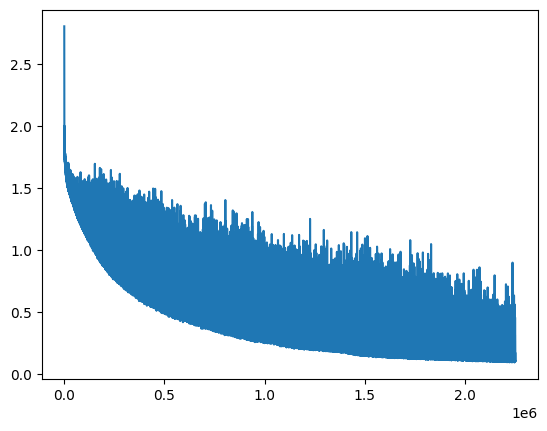

In [29]:
model2 = nn.Sequential(

    nn.Linear(4,400),

    nn.ReLU(),

    nn.Linear(400,400),

    nn.ReLU(),

    nn.Linear(400,400),
    
    nn.ReLU(),

    nn.Linear(400,400),
    
    nn.ReLU(),

    nn.Linear(400,400),
    
    nn.ReLU(),

    nn.Linear(400,400),
    
    nn.ReLU(),

    nn.Linear(400,400),
    
    nn.ReLU(),

    nn.Linear(400,400),
    
    nn.ReLU(),

    nn.Linear(400,2)

).to(device)

#ReLU라는 Activation Function을 사용하여, 4개의 Linear Layer로 모델 구현

# Input layer에 1개씩 데이터가 들어가므로 nn.Linear(1,2)이며, 최종적으로 1개의 값이 나와야하기에 Output Layer는 nn.Linear(4,1)

 

loss_func = nn.L1Loss().to(device)

# optimizer = optim.SGD(model.parameters(),lr = 0.0002)

# optimizer = adabound.AdaBound(model.parameters(), lr=0.935 * 1e-4, final_lr=0.05758)  #Loss: 0.0537

# optimizer = adabound.AdaBound(model.parameters(), lr=0.435 * 1e-3, final_lr=0.05558)

optimizer = adabound.AdaBound(model2.parameters(), lr=0.935 * 1e-3, final_lr=0.05958)  #Loss: 0.0537

loss_array = []

minloss = 10

for i in tqdm(range(num_epoch)) : 

    optimizer.zero_grad()

    output = model2(x22)

    loss = loss_func(output,y22)

    loss.backward()

    optimizer.step()

    if(loss < minloss):
       minloss = loss

    loss_array.append(loss)
    if(i == 1):
      stdout.write("Minimum loss: " + str(minloss))
    if(i%100000 == 0 and i != 0):
      # print("Case "+ str(i) + ", Loss: " + str(loss.data))
      stdout.write("Minimum loss: " + str(minloss))

    if i == num_epoch - 1:

        print(loss.data)

        param_list = list(model.parameters())

        #최종 학습된 마지막 결과물의 Parameter 저장

        print(param_list)

loss_array = torch.tensor(loss_array)

loss_array.detach().numpy()

plt.plot(loss_array)

plt.show()

#Loss(y_predicted - y_real)값이 어떻게 변하는지 그래프로 도식화

In [30]:
from datetime import datetime as dt 
date = dt.now()

printdate = date.strftime('%Y%m%d_%H%M%S')
print(date)

torch.save(model2.state_dict(), "Zmodel2_" + printdate + ".h5")

2023-04-20 09:21:57.084097


In [31]:
X_input = list(np.array(X_valid.values.tolist()))
new_var =  torch.FloatTensor(X_input).to(device)
y_input2 = model2(new_var)
y_input2 = np.array(y_input2.tolist())
y_input2

y_output2 = np.array(y_valid.values.tolist())
y_output2

array([[0.949375  , 1.        ],
       [0.119375  , 4.        ],
       [0.12843749, 1.        ],
       ...,
       [0.09294756, 1.        ],
       [0.26633943, 4.        ],
       [0.34453125, 1.        ]])

In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# MAE
print("Z tau MAE: " + str(mean_absolute_error(y_input2[:, 0], y_output2[:, 0])))
print("Z N MAE: " + str(mean_absolute_error(y_input2[:, 1], y_output2[:, 1])))
# print("Z tau MAE: " + str(mean_absolute_error(y_input[:, 2], y_output[:, 2])))
# print("Z N MAE: " + str(mean_absolute_error(y_input[:, 3], y_output[:, 3])))

print(' ')
#MSE
print("Z tau MSE: " + str(mean_squared_error(y_input2[:, 0], y_output2[:, 0])))
print("Z N MSE: " + str(mean_squared_error(y_input2[:, 1], y_output2[:, 1])))
# print("Z tau MSE: " + str(mean_squared_error(y_input[:, 2], y_output[:, 2])))
# print("Z N MSE: " + str(mean_squared_error(y_input[:, 3], y_output[:, 3])))

print(' ')
#r2
print("Z tau r2: " + str(r2_score(y_input2[:, 0], y_output2[:, 0])))
print("Z N r2: " + str(r2_score(y_input2[:, 1], y_output2[:, 1])))
# print("Z tau r2: " + str(r2_score(y_input[:, 2], y_output[:, 2])))
# print("Z N r2: " + str(r2_score(y_input[:, 3], y_output[:, 3])))

Z tau MAE: 0.3217081196738053
Z N MAE: 4.340432887823403
 
Z tau MSE: 0.24843798412241055
Z N MSE: 50.75934672972817
 
Z tau r2: -0.2971517713568492
Z N r2: -0.9079955123609575


In [157]:
# Al = 2*math.pi*0.3
# Ap = 2*math.pi*0.3

number = 16

# Al    = 2*pi * random.uniform(0.05, 0.8) #[MHz] # A_|| hyperfine term
# Ap = 2*pi* random.uniform(0.05, 0.3) #[MHz] # A_per hyperfine term

Alarr = X_valid[['Al']]
Aparr = X_valid[['Ap']]
Alarr = list(np.array(Alarr))
Aparr = list(np.array(Aparr))



Al = Alarr[number]
Ap = Aparr[number]

Al = float(Al)
Ap = float(Ap)
AAin = torch.FloatTensor([[Al, Ap]]).to(device)

AA_predict = model(AAin)

AAA_predict = np.array(AA_predict.tolist())

In [158]:
AA_predict = AA_predict.tolist()
list(np.array(AA_predict))
AA_predict[0][1]

13.004240036010742

In [159]:
AAin2 = torch.FloatTensor([Al, Ap, AA_predict[0][0], AA_predict[0][1]]).to(device)
AAin2
# AAin2
# AAXtau = AA

tensor([ 4.3986,  0.9043,  2.8826, 13.0042], device='cuda:0')

In [160]:
AA2_predict = model2(AAin2)
AA2_predict = AA2_predict.cpu()
AA2_predict

tensor([0.6127, 1.0218], grad_fn=<ToCopyBackward0>)

In [ ]:
aa = []
cc = []
dd = []
count = 1
tot_sum = 0
tolN = 1e-15

for ccc in tqdm(range(1)): # range 번의 실험을 진행한다.
    trace = [1, 1, 0, 100, 100, 1000, 100]
    vvv = [0, 0, 0, 0]
    bbb = [0, 0, 0, 0]
    normalxyz = [0, 0, 0]
    start = time.time()
    #for making 13C nuclear random dataset
    gammaN = 2*pi*1.071e-3 #[MHz/G]
    # Al    = 2*pi * random.uniform(0.05, 0.8) #[MHz] # A_|| hyperfine term
    # Ap = 2*pi* random.uniform(0.05, 0.3) #[MHz] # A_per hyperfine term
    Al = Alarr[number]
    Ap = Aparr[number]

    #Initialization
    rho_0 = (np.kron(U090xp,I))@irho@((np.kron(U090xp,I)).conj().T) # superposition state on NV

    Sa= []

    ham = Al*np.kron(sz,Iz) + Ap*np.kron(sz,Ix) + B*gammaN*np.kron(I,Iz) # Hamiltonian
    eigvals = np.linalg.eigh(ham)[0]            # diagonalizing the Hamiltonian 여기서부터 문제 
    eigvecs = -1*np.linalg.eigh(ham)[1]         # eigenvectors
    E = np.diag(eigvals)                        # exponent of eigenvalues
    U_H= eigvecs.conj().T                       # unitary matrix formed by eigenvectors
    

    for p in range(1): # 1번의 실험을 진행한다.(지역 최적화 알고리즘을 사용할 경우에 수정한다.)
        vari=[AA_predict[0][0], AA_predict[0][1], AA2_predict[0], AA2_predict[1]]  #초기값
        # bounds = [(0.85*tau,1.15*tau),(1.0,25.0),(0.00000000000000000001*tau,0.5*tau),(1.0,25.0)] #boundary
        if(AA_predict[0][1] < mean_absolute_error(y_input[:, 1], y_output[:, 1]) + 1):
            min_AA = 1
        else:
            min_AA = AA_predict[0][1] - mean_absolute_error(y_input[:, 1], y_output[:, 1])/2
        if(AA2_predict[1] < mean_absolute_error(y_input2[:, 1], y_output2[:, 1]) + 1):
            min_AA2 = 1   
        else:
            min_AA2 = AA2_predict - mean_absolute_error(y_input2[:, 1], y_output2[:, 1])/2
        bounds = [(float(AA_predict[0][0]) * float(1 - mean_absolute_error(y_input[:, 0], y_output[:, 0])), float(AA_predict[0][1]) * float(1 + mean_absolute_error(y_input[:, 0], y_output[:, 0]))), 
                  (min_AA, float(AA_predict[0][1] + mean_absolute_error(y_input[:, 1], y_output[:, 1]))), (float(AA2_predict[0]) * float(1 - mean_absolute_error(y_input2[:, 0], y_output2[:, 0])/2), float(AA2_predict[0]) * float(1 + mean_absolute_error(y_input2[:, 0], y_output2[:, 0])/2)), 
                  (min_AA2, float(AA2_predict[1] + mean_absolute_error(y_input2[:, 1], y_output2[:, 1])/2))]
        res4 = optimize.shgo(problem,bounds=bounds,iters=5,options={'xtol':1e-4,'ftol':1e-4}) #SHGO method
        # res4 = optimize.minimize(problem, AAdata, bounds=bounds ,method='Nelder-Mead',options={'xtol':tolN,'ftol':tolN}) #Nelder-Mead method
        res4['x'][1] = round(res4['x'][1]) #rounding
        res4['x'][3] = round(res4['x'][3]) #rounding
        dd.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])
        # cc.append([Al, Ap, trace[4], vvv[0], vvv[1], vvv[2], vvv[3], trace[0], trace[1], trace[2], res4["nfev"]])
        cc.append([Al, Ap, res4['fun'], res4['x'][0], res4['x'][1], res4['x'][2], res4['x'][3]])
        # aa.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])

        # if(np.abs(res4['fun']) < 0.1 and trace[0] != 1): #fidelity가 0.05보다 작으면 성공
        #     dd.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])
        #     cc.append([Al, Ap, trace[4], vvv[0], vvv[1], vvv[2], vvv[3], trace[0], trace[1], trace[2], res4["nfev"]])
        #     end = time.time()
        #     final = end - start
        #     count = count + 1
        # else:
        #     aa.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])
        #     end = time.time()
        #     final = end - start
        #     count = count + 1


# 결과들을 list에 저장하여 csv파일로 저장


print('success')

totalend = time.time()
print(totalend - totalstart)

print(dd)
print(cc)
aa = []
cc = []
dd = []
count = 1
tot_sum = 0
tolN = 1e-15

for ccc in tqdm(range(1)): # range 번의 실험을 진행한다.
    trace = [1, 1, 0, 100, 100, 1000, 100]
    vvv = [0, 0, 0, 0]
    bbb = [0, 0, 0, 0]
    normalxyz = [0, 0, 0]
    start = time.time()
    #for making 13C nuclear random dataset
    gammaN = 2*pi*1.071e-3 #[MHz/G]
    # Al    = 2*pi * random.uniform(0.05, 0.8) #[MHz] # A_|| hyperfine term
    # Ap = 2*pi* random.uniform(0.05, 0.3) #[MHz] # A_per hyperfine term
    Al = Alarr[number]
    Ap = Aparr[number]

    #Initialization
    rho_0 = (np.kron(U090xp,I))@irho@((np.kron(U090xp,I)).conj().T) # superposition state on NV

    Sa= []

    ham = Al*np.kron(sz,Iz) + Ap*np.kron(sz,Ix) + B*gammaN*np.kron(I,Iz) # Hamiltonian
    eigvals = np.linalg.eigh(ham)[0]            # diagonalizing the Hamiltonian 여기서부터 문제 
    eigvecs = -1*np.linalg.eigh(ham)[1]         # eigenvectors
    E = np.diag(eigvals)                        # exponent of eigenvalues
    U_H= eigvecs.conj().T                       # unitary matrix formed by eigenvectors
    

    for p in range(1): # 1번의 실험을 진행한다.(지역 최적화 알고리즘을 사용할 경우에 수정한다.)
        vari=[AA_predict[0][0], AA_predict[0][1], AA2_predict[0], AA2_predict[1]]  #초기값
        # bounds = [(0.85*tau,1.15*tau),(1.0,25.0),(0.00000000000000000001*tau,0.5*tau),(1.0,25.0)] #boundary
        if(AA_predict[0][1] < mean_absolute_error(y_input[:, 1], y_output[:, 1]) + 1):
            min_AA = 1
        else:
            min_AA = AA_predict[0][1] - mean_absolute_error(y_input[:, 1], y_output[:, 1])/2
        if(AA2_predict[1] < mean_absolute_error(y_input2[:, 1], y_output2[:, 1]) + 1):
            min_AA2 = 1   
        else:
            min_AA2 = AA2_predict - mean_absolute_error(y_input2[:, 1], y_output2[:, 1])/2
        bounds = [(float(AA_predict[0][0]) * float(1 - mean_absolute_error(y_input[:, 0], y_output[:, 0])), float(AA_predict[0][1]) * float(1 + mean_absolute_error(y_input[:, 0], y_output[:, 0]))), 
                  (min_AA, float(AA_predict[0][1] + mean_absolute_error(y_input[:, 1], y_output[:, 1]))), (float(AA2_predict[0]) * float(1 - mean_absolute_error(y_input2[:, 0], y_output2[:, 0])/2), float(AA2_predict[0]) * float(1 + mean_absolute_error(y_input2[:, 0], y_output2[:, 0])/2)), 
                  (min_AA2, float(AA2_predict[1] + mean_absolute_error(y_input2[:, 1], y_output2[:, 1])/2))]
        # res4 = optimize.shgo(problem,bounds=bounds,iters=5,options={'xtol':1e-4,'ftol':1e-4}) #SHGO method
        res4 = optimize.minimize(problem, AAdata, bounds=bounds ,method='Nelder-Mead',options={'xtol':tolN,'ftol':tolN}) #Nelder-Mead method
        res4['x'][1] = round(res4['x'][1]) #rounding
        res4['x'][3] = round(res4['x'][3]) #rounding
        dd.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])
        # cc.append([Al, Ap, trace[4], vvv[0], vvv[1], vvv[2], vvv[3], trace[0], trace[1], trace[2], res4["nfev"]])
        cc.append([Al, Ap, res4['fun'], res4['x'][0], res4['x'][1], res4['x'][2], res4['x'][3]])


print('success')

totalend = time.time()
print(totalend - totalstart)

print(dd)
print(cc)

In [ ]:
# aa = []
# cc = []
# dd = []
# count = 1
# tot_sum = 0
# tolN = 1e-15

# for ccc in tqdm(range(1)): # range 번의 실험을 진행한다.
#     trace = [1, 1, 0, 100, 100, 1000, 100]
#     vvv = [0, 0, 0, 0]
#     bbb = [0, 0, 0, 0]
#     normalxyz = [0, 0, 0]
#     start = time.time()
#     #for making 13C nuclear random dataset
#     gammaN = 2*pi*1.071e-3 #[MHz/G]
#     # Al    = 2*pi * random.uniform(0.05, 0.8) #[MHz] # A_|| hyperfine term
#     # Ap = 2*pi* random.uniform(0.05, 0.3) #[MHz] # A_per hyperfine term
#     Al = Alarr[number]
#     Ap = Aparr[number]

#     #Initialization
#     rho_0 = (np.kron(U090xp,I))@irho@((np.kron(U090xp,I)).conj().T) # superposition state on NV

#     Sa= []

#     ham = Al*np.kron(sz,Iz) + Ap*np.kron(sz,Ix) + B*gammaN*np.kron(I,Iz) # Hamiltonian
#     eigvals = np.linalg.eigh(ham)[0]            # diagonalizing the Hamiltonian 여기서부터 문제 
#     eigvecs = -1*np.linalg.eigh(ham)[1]         # eigenvectors
#     E = np.diag(eigvals)                        # exponent of eigenvalues
#     U_H= eigvecs.conj().T                       # unitary matrix formed by eigenvectors
    

#     for p in range(1): # 1번의 실험을 진행한다.(지역 최적화 알고리즘을 사용할 경우에 수정한다.)
#         vari=[AA_predict[0][0], AA_predict[0][1], AA2_predict[0], AA2_predict[1]]  #초기값
#         # bounds = [(0.85*tau,1.15*tau),(1.0,25.0),(0.00000000000000000001*tau,0.5*tau),(1.0,25.0)] #boundary
#         if(AA_predict[0][1] < mean_absolute_error(y_input[:, 1], y_output[:, 1]) + 1):
#             min_AA = 1
#         else:
#             min_AA = AA_predict[0][1] - mean_absolute_error(y_input[:, 1], y_output[:, 1])/2
#         if(AA2_predict[1] < mean_absolute_error(y_input2[:, 1], y_output2[:, 1]) + 1):
#             min_AA2 = 1   
#         else:
#             min_AA2 = AA2_predict - mean_absolute_error(y_input2[:, 1], y_output2[:, 1])/2
#         bounds = [(float(AA_predict[0][0]) * float(1 - mean_absolute_error(y_input[:, 0], y_output[:, 0])), float(AA_predict[0][1]) * float(1 + mean_absolute_error(y_input[:, 0], y_output[:, 0]))), 
#                   (min_AA, float(AA_predict[0][1] + mean_absolute_error(y_input[:, 1], y_output[:, 1]))), (float(AA2_predict[0]) * float(1 - mean_absolute_error(y_input2[:, 0], y_output2[:, 0])/2), float(AA2_predict[0]) * float(1 + mean_absolute_error(y_input2[:, 0], y_output2[:, 0])/2)), 
#                   (min_AA2, float(AA2_predict[1] + mean_absolute_error(y_input2[:, 1], y_output2[:, 1])/2))]
#         res4 = optimize.shgo(problem,bounds=bounds,iters=5,options={'xtol':1e-4,'ftol':1e-4}) #SHGO method
#         # res4 = optimize.minimize(problem, AAdata, bounds=bounds ,method='Nelder-Mead',options={'xtol':tolN,'ftol':tolN}) #Nelder-Mead method
#         res4['x'][1] = round(res4['x'][1]) #rounding
#         res4['x'][3] = round(res4['x'][3]) #rounding
#         dd.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])
#         # cc.append([Al, Ap, trace[4], vvv[0], vvv[1], vvv[2], vvv[3], trace[0], trace[1], trace[2], res4["nfev"]])
#         cc.append([Al, Ap, res4['fun'], res4['x'][0], res4['x'][1], res4['x'][2], res4['x'][3]])
#         # aa.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])

#         # if(np.abs(res4['fun']) < 0.1 and trace[0] != 1): #fidelity가 0.05보다 작으면 성공
#         #     dd.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])
#         #     cc.append([Al, Ap, trace[4], vvv[0], vvv[1], vvv[2], vvv[3], trace[0], trace[1], trace[2], res4["nfev"]])
#         #     end = time.time()
#         #     final = end - start
#         #     count = count + 1
#         # else:
#         #     aa.append([Al, Ap, trace[6], bbb[0], bbb[1], bbb[2], bbb[3], normalxyz[0], normalxyz[1], normalxyz[2], res4['nfev']])
#         #     end = time.time()
#         #     final = end - start
#         #     count = count + 1


# # 결과들을 list에 저장하여 csv파일로 저장


# print('success')

# totalend = time.time()
# print(totalend - totalstart)

# print(dd)
# print(cc)